In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
import celloracle as co
co.__version__




'0.18.0'

In [3]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

In [4]:
save_folder = "figures"
os.makedirs(save_folder, exist_ok=True)



In [5]:
###Preparing the data

In [ ]:
adata = sc.read_h5ad('joun_1171_genes_mCherry_controls.h5ad')  ## Google Drive: gCAL_data > Joung2013_results
adata

AnnData object with n_obs × n_vars = 4000 × 1171
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF'
    var: 'n_cells-0-0', 'n_cells-0-1-0', 'n_cells-1-1-0', 'n_cells-2-1-0', 'n_cells-3-1-0', 'n_cells-0-2-0', 'n_cells-1-2-0', 'n_cells-2-2-0', 'n_cells-3-2-0', 'n_cells-0-3-0', 'n_cells-1-3-0', 'n_cells-2-3-0', 'n_cells-3-3-0', 'n_cells-0-4-0', 'n_cells-1-4-0', 'n_cells-2-4-0', 'n_cells-3-4-0', 'n_cells-0-1', 'n_cells-1-1', 'n_cells-2-1', 'n_cells-3-1'

In [7]:
adata.obs["cell_type"] = "ehgc"


In [8]:
adata.obs["cell_type"]

R1.41,R2.50,R3.41,P1.62-3-1    ehgc
R1.37,R2.04,R3.95,P1.22-0-1    ehgc
R1.52,R2.29,R3.19,P1.30-1-1    ehgc
R1.01,R2.65,R3.67,P1.30-1-1    ehgc
R1.39,R2.73,R3.45,P1.62-3-1    ehgc
                               ... 
R1.96,R2.82,R3.11,P1.22-0-1    ehgc
R1.14,R2.45,R3.10,P1.30-1-1    ehgc
R1.47,R2.48,R3.96,P1.38-2-1    ehgc
R1.50,R2.37,R3.43,P1.62-3-1    ehgc
R1.92,R2.10,R3.64,P1.22-0-1    ehgc
Name: cell_type, Length: 4000, dtype: object

In [9]:
adata.var["gene_symbols"] = adata.var_names

In [10]:
adata.var_names = adata.var["gene_symbols"]

In [11]:
#idx = adata.obs.condition == 'ctrl'

In [12]:
#adata = adata[idx, :]

In [13]:
adata.var_names

Index(['A1CF', 'A3GALT2', 'AACSP1', 'ABCA10', 'ABCA7', 'ABCB1', 'ABCC9', 'ABR',
       'ACADSB', 'ACER1',
       ...
       'ZNF345', 'ZNF385B', 'ZNF385D', 'ZNF488', 'ZNF491', 'ZNF521', 'ZNF540',
       'ZNF560', 'ZNF75D', 'ZNF99'],
      dtype='object', name='gene_symbols', length=1171)

In [14]:
sc.tl.pca(adata)

In [15]:
#adata.layers['normalized'] = adata.X.copy()
#adata.X = adata.layers['counts'].copy()

In [16]:
print(f"Cell number is :{adata.shape[0]}")
print(f"Gene number is :{adata.shape[1]}")

Cell number is :4000
Gene number is :1171


In [17]:
###Analysis

In [ ]:
base_GRN = pd.read_parquet("hg38_TFinfo_dataframe_gimmemotifsv5_fpr2_threshold_10_20210630.parquet") ## Google Drive: gCAL_data > Joung2013_results

In [19]:
#base_GRN = co.data.load_human_promoter_base_GRN()

In [20]:
base_GRN.head()

,peak_id,gene_short_name,9430076C15RIK,AC002126.6,AC012531.1,AC226150.2,AFP,AHR,AHRR,AIRE,...,ZNF784,ZNF8,ZNF816,ZNF85,ZSCAN10,ZSCAN16,ZSCAN22,ZSCAN26,ZSCAN31,ZSCAN4
0,chr10_100009853_100010953,DNMBP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr10_100081785_100082885,CPN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,chr10_100185877_100186977,ERLIN1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr10_100186978_100187057,ERLIN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr10_100229510_100230610,CHUK,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
TF_names = list(set(base_GRN.columns).intersection(set(adata.var_names)))

print(f"Number of TFs matched to expression matrix: {len(TF_names)}")

Number of TFs matched to expression matrix: 47


In [22]:
base_GRN["gene_short_name"]

0          DNMBP
1           CPN1
2         ERLIN1
3         ERLIN1
4           CHUK
          ...   
39310    TTTY21B
39311      TTTY2
39312     TTTY1B
39313     TTTY22
39314    TTTY23B
Name: gene_short_name, Length: 39315, dtype: object

In [23]:
len(set(adata.var_names).intersection(set(base_GRN["gene_short_name"])))

1171

In [24]:
### Make Oracle Object

In [25]:
oracle = co.Oracle()

In [26]:
# Check data in anndata
print("Metadata columns :", list(adata.obs.columns))
print("Dimensional reduction: ", list(adata.obsm.keys()))

Metadata columns : ['n_genes', 'percent_mito', 'n_counts', 'batch', 'TF', 'cell_type']
Dimensional reduction:  ['X_pca']


... storing 'cell_type' as categorical


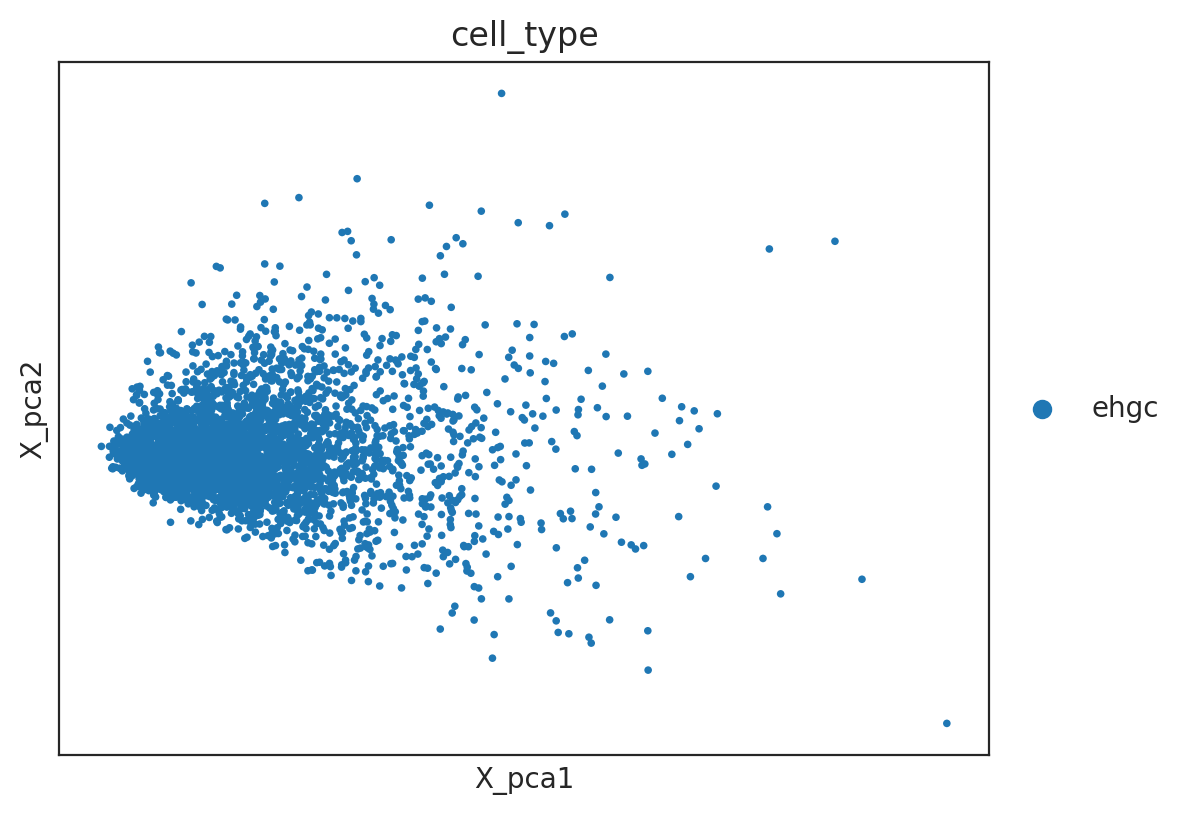

In [27]:
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="cell_type",
                                   embedding_name="X_pca")

In [28]:
oracle.import_TF_data(TF_info_matrix=base_GRN)

Total number of TF was 47. Although we can go to the GRN calculation with this data, but the TF number is small.


In [29]:
##KNN imputation

In [30]:
oracle.perform_PCA()

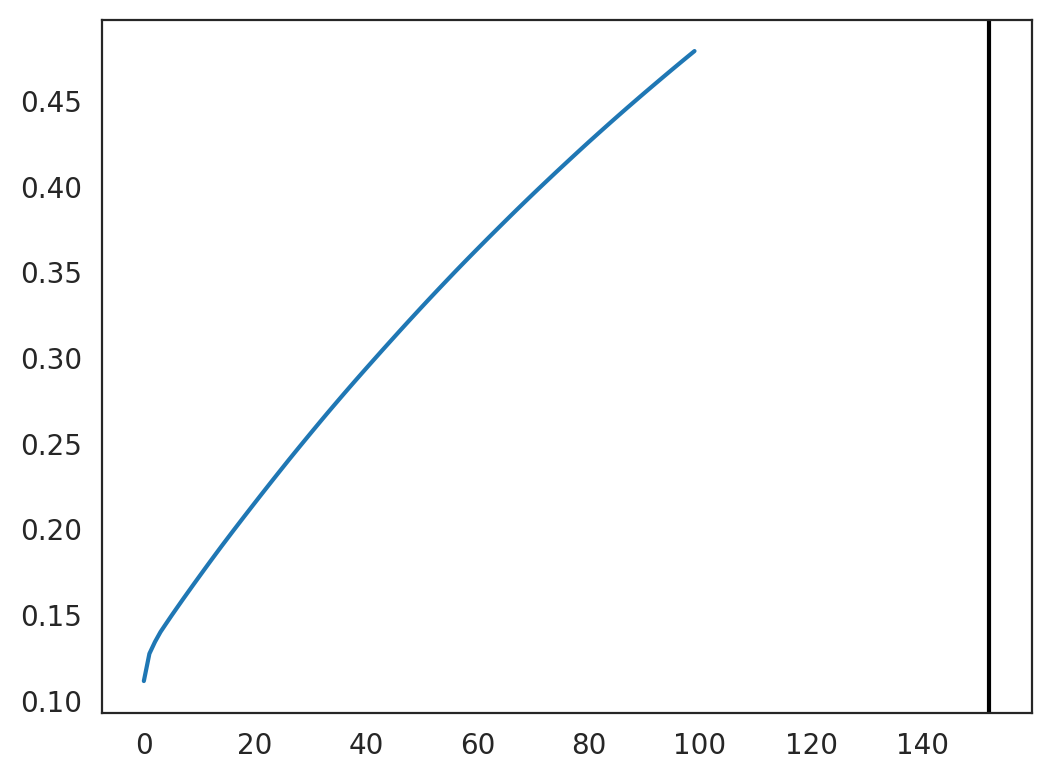

152


In [31]:
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)

In [32]:
n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")

cell number is :4000


In [33]:
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

Auto-selected k is :100


In [34]:
print(oracle)

Oracle object

Meta data
    celloracle version used for instantiation: 0.18.0
    n_cells: 4000
    n_genes: 1171
    cluster_name: cell_type
    dimensional_reduction_name: X_pca
    n_target_genes_in_TFdict: 27314 genes
    n_regulatory_in_TFdict: 1094 genes
    n_regulatory_in_both_TFdict_and_scRNA-seq: 47 genes
    n_target_genes_both_TFdict_and_scRNA-seq: 1171 genes
    k_for_knn_imputation: NA
Status
    Gene expression matrix: Ready
    BaseGRN: Ready
    PCA calculation: Done
    Knn imputation: Not finished
    GRN calculation for simulation: Not finished



In [35]:
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=4)


In [36]:
###Save Oracle Data

In [37]:
oracle.to_hdf5("ehgc_oracle_data.celloracle.oracle")

In [38]:
###Load Oracle Data

In [39]:
oracle = co.load_hdf5("ehgc_oracle_data.celloracle.oracle")

In [40]:
###GRN calculation

In [41]:
sc.pp.neighbors(oracle.adata)


In [42]:
sc.tl.draw_graph(oracle.adata)


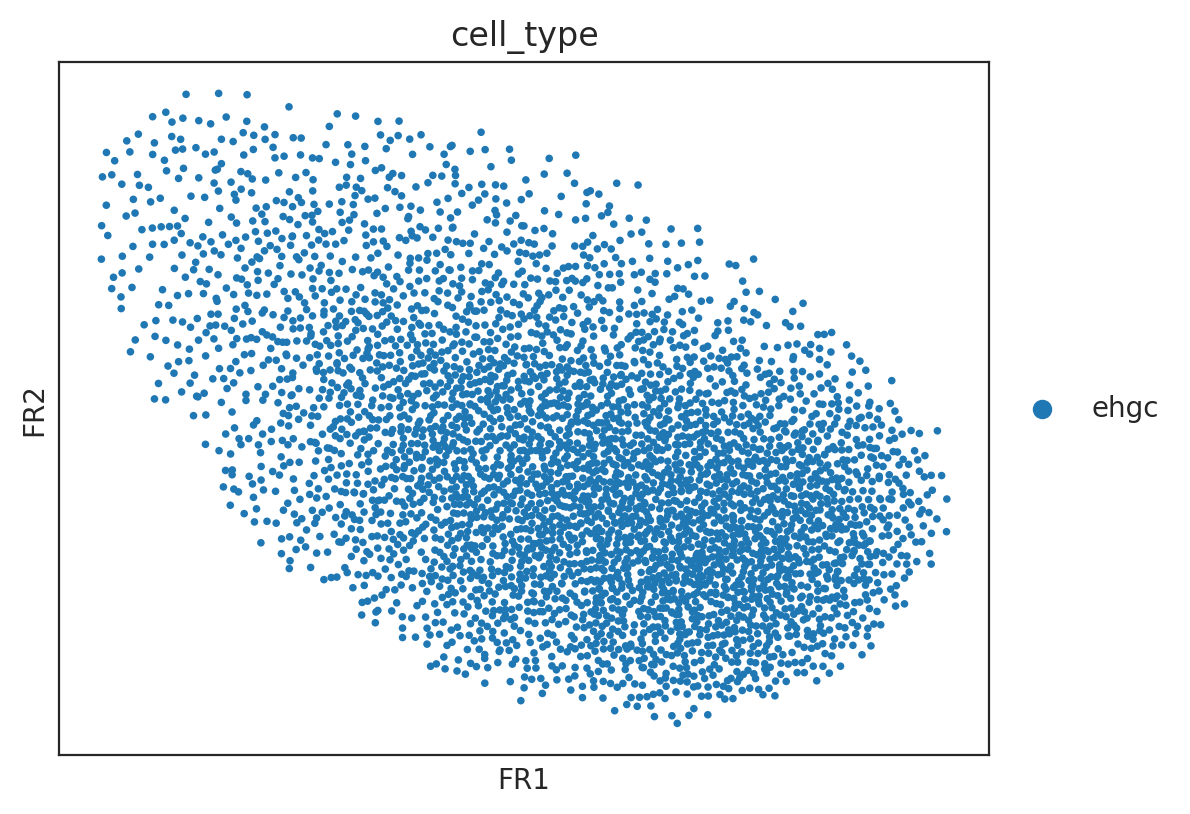

In [43]:
sc.pl.draw_graph(oracle.adata, color="cell_type")

In [44]:
%%time
# Calculate GRN for each population in "louvain_annot" clustering unit.
# This step may take some time.(~30 minutes)
links = oracle.get_links(cluster_name_for_GRN_unit="cell_type", alpha=10,
                         verbose_level=10)



  0%|          | 0/1 [00:00<?, ?it/s]

Inferring GRN for ehgc...


  0%|          | 0/1171 [00:00<?, ?it/s]

CPU times: user 23.6 s, sys: 2.73 s, total: 26.3 s
Wall time: 33.7 s


In [45]:
links.links_dict.keys()

dict_keys(['ehgc'])

In [46]:
cluster = "ehgc"

In [47]:
links.links_dict[cluster].to_csv(f"raw_GRN_for_{cluster}.csv")

In [48]:
links.to_hdf5(file_path="links.celloracle.links")

In [49]:
##Filtering (which isn't necessary, but the plotting needs it)

In [50]:
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)

In [51]:
plt.rcParams["figure.figsize"] = [9, 4.5]

ehgc


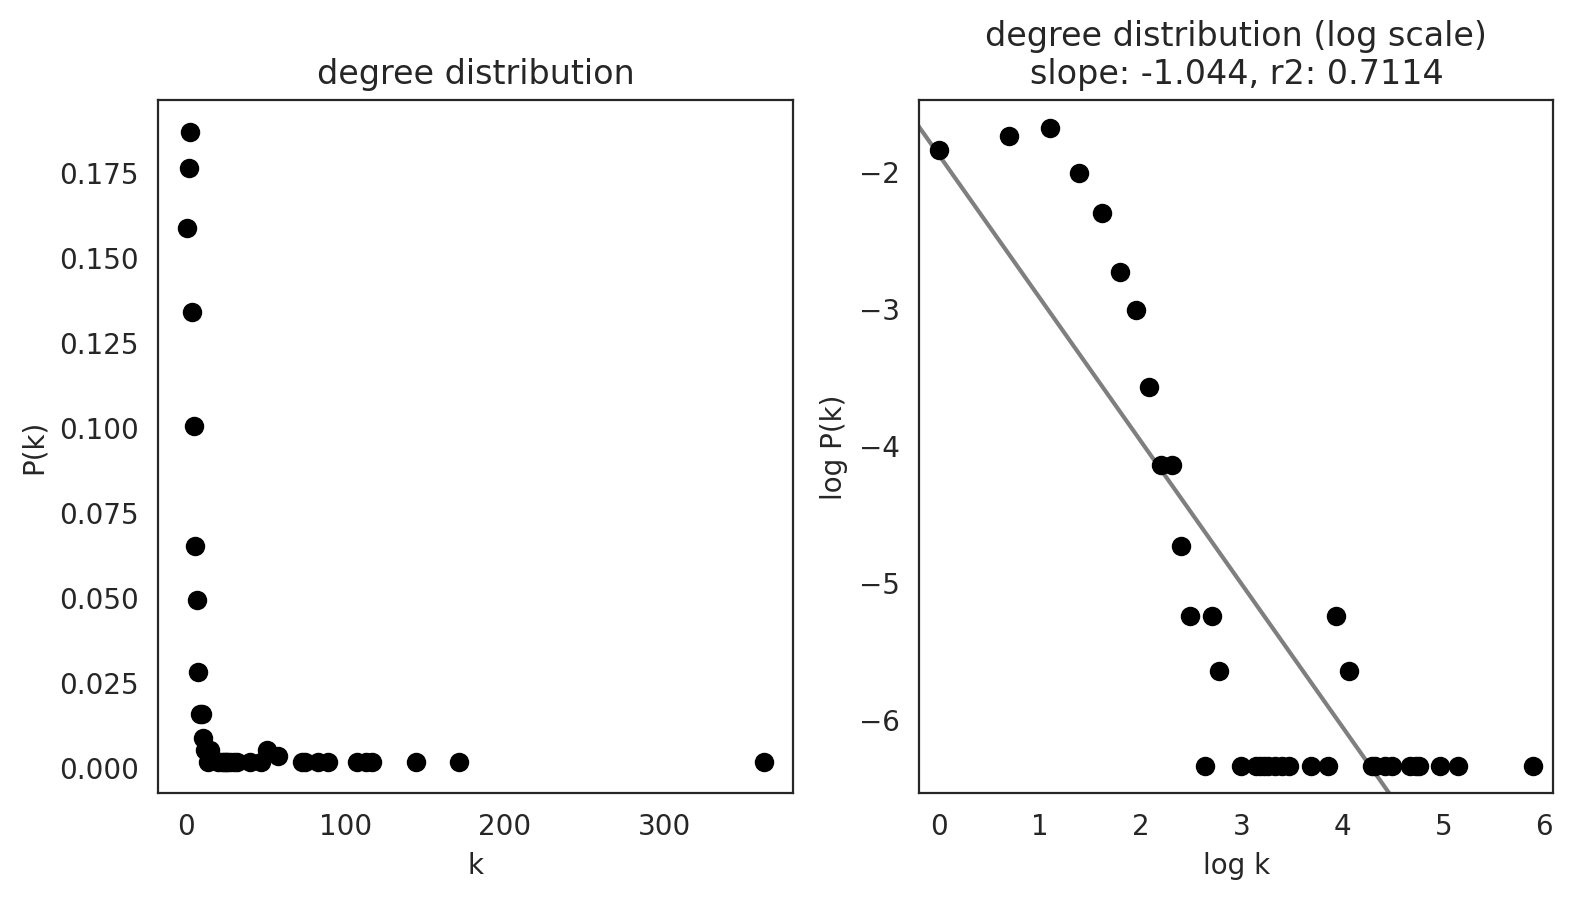

In [52]:
links.plot_degree_distributions(plot_model=True,
                                               save="figures/degree_distribution/",
                                               )

In [53]:
##Trying to plot without filtering

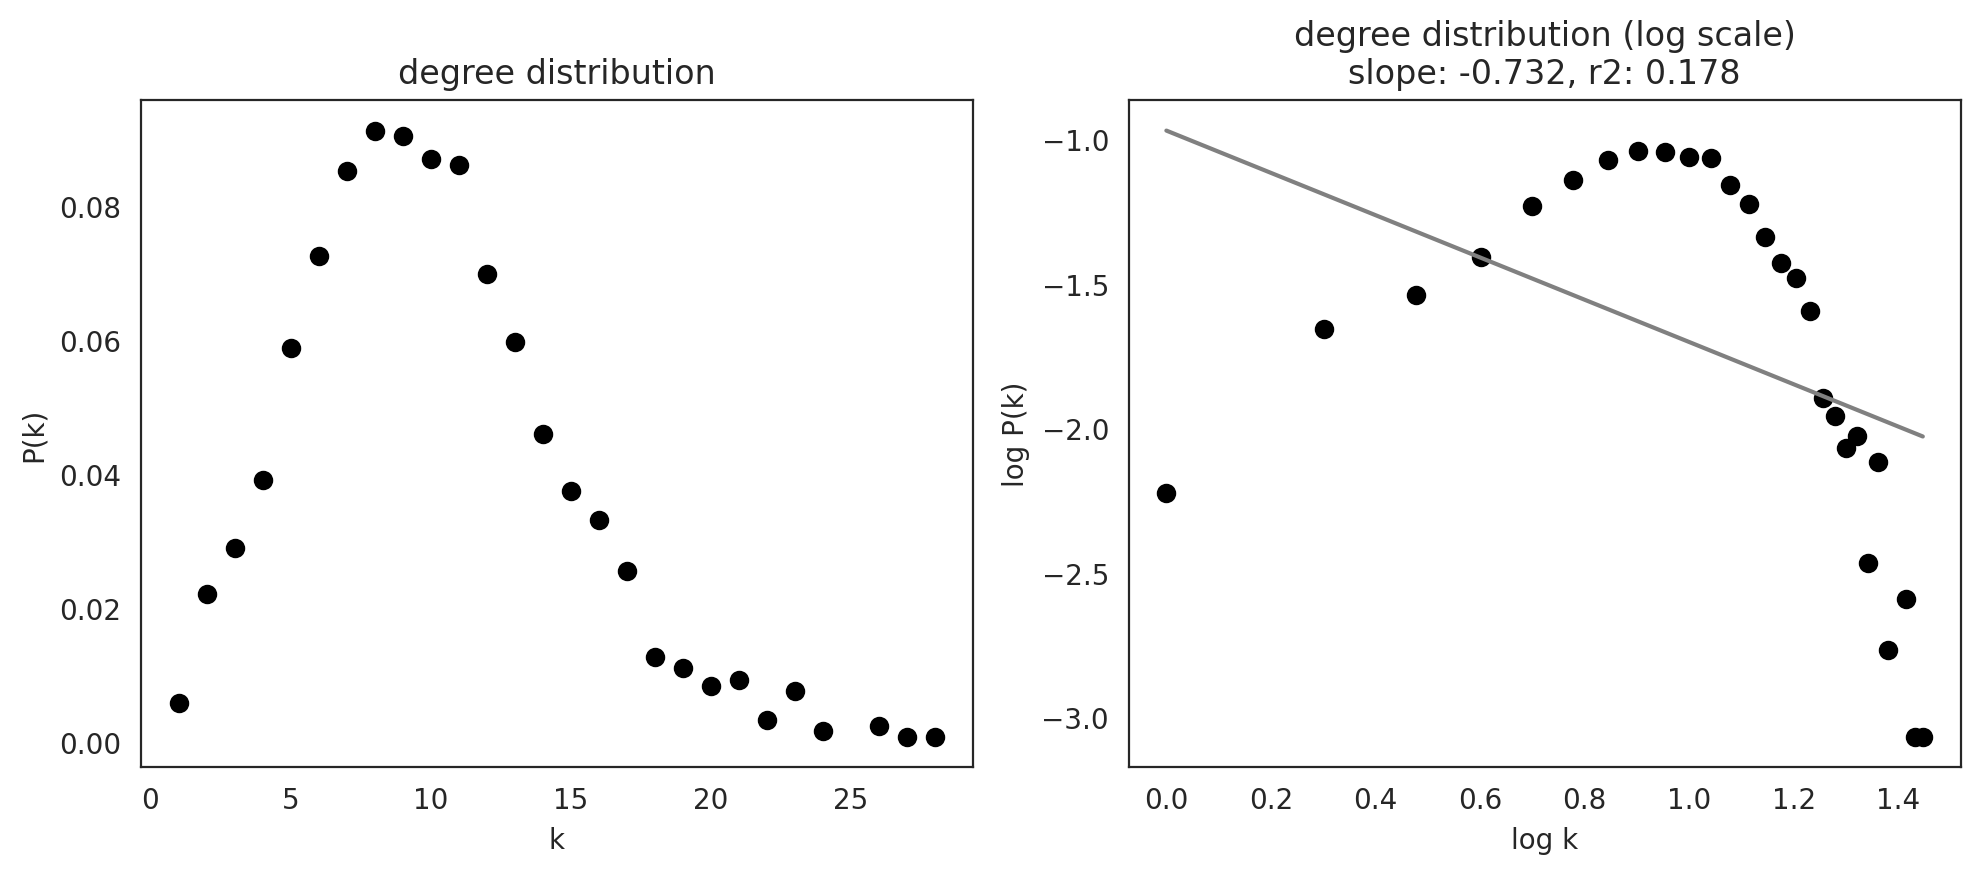

In [54]:
raw_grn_df = links.links_dict["ehgc"]

# Step 2: Compute in-degree (number of TFs targeting each gene)
in_deg = raw_grn_df["target"].value_counts()
deg_freq = in_deg.value_counts().sort_index()
probability = deg_freq / deg_freq.sum()

# Step 3: Prepare log-log values for linear fit
log_k = np.log10(deg_freq.index)
log_p = np.log10(probability)

slope, intercept = np.polyfit(log_k, log_p, 1)
r2 = np.corrcoef(log_k, log_p)[0, 1] ** 2

# Step 4: Plot
plt.figure(figsize=(10, 4.5))

# Left panel: degree distribution
plt.subplot(1, 2, 1)
plt.scatter(deg_freq.index, probability, color='black')
plt.xlabel("k")
plt.ylabel("P(k)")
plt.title("degree distribution")

# Right panel: log-log plot
plt.subplot(1, 2, 2)
plt.scatter(log_k, log_p, color='black')
plt.plot(log_k, slope * log_k + intercept, color='gray')
plt.xlabel("log k")
plt.ylabel("log P(k)")
plt.title(f"degree distribution (log scale)\nslope: {slope:.3f}, r2: {r2:.3f}")

plt.tight_layout()
plt.savefig("figures/degree_distribution/raw_degree_distribution.png")
plt.show()

In [55]:
##Network scores on filtered data

In [56]:
links.get_network_score()

In [57]:
links.merged_score.head()

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
GLI2,83,0.146643,2,0.003534,81,0.143110,236.0,0.294668,ehgc
TERF1,1,0.001767,1,0.001767,0,0.000000,0.0,0.073089,ehgc
NR3C1,364,0.643110,2,0.003534,362,0.639576,2541.0,1.000000,ehgc
GRID2,9,0.015901,9,0.015901,0,0.000000,0.0,0.304664,ehgc
BACH2,58,0.102473,4,0.007067,54,0.095406,186.0,0.127375,ehgc


In [58]:
##saving Oracle file

links.to_hdf5(file_path="links.celloracle.links")

In [59]:
##Visualize genes with high Centrality

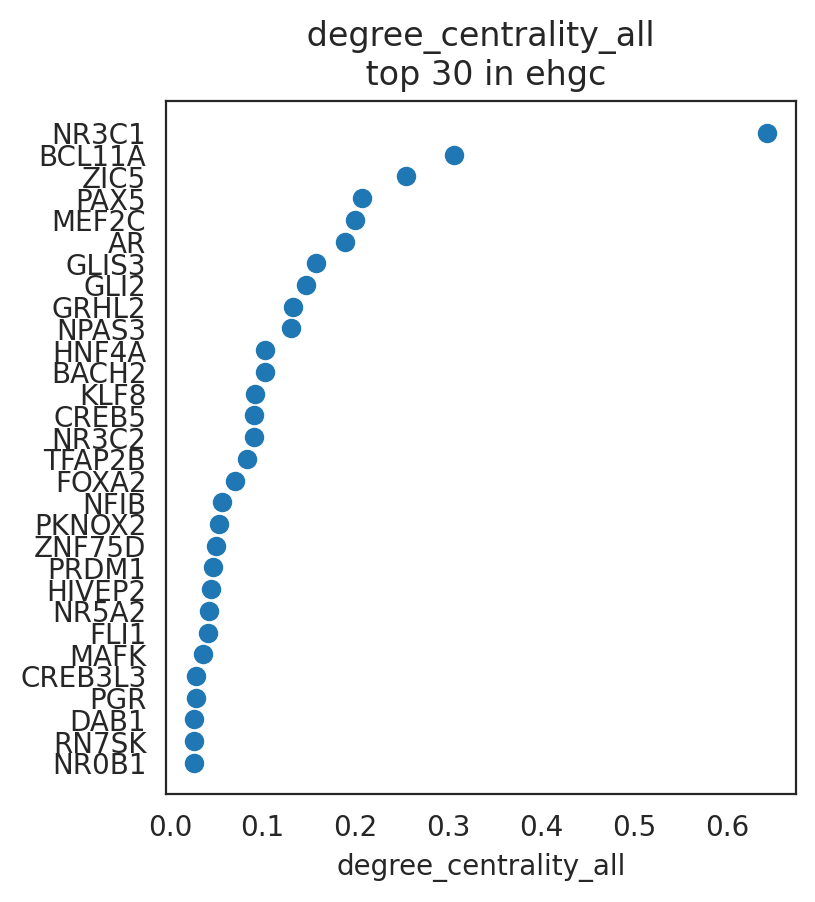

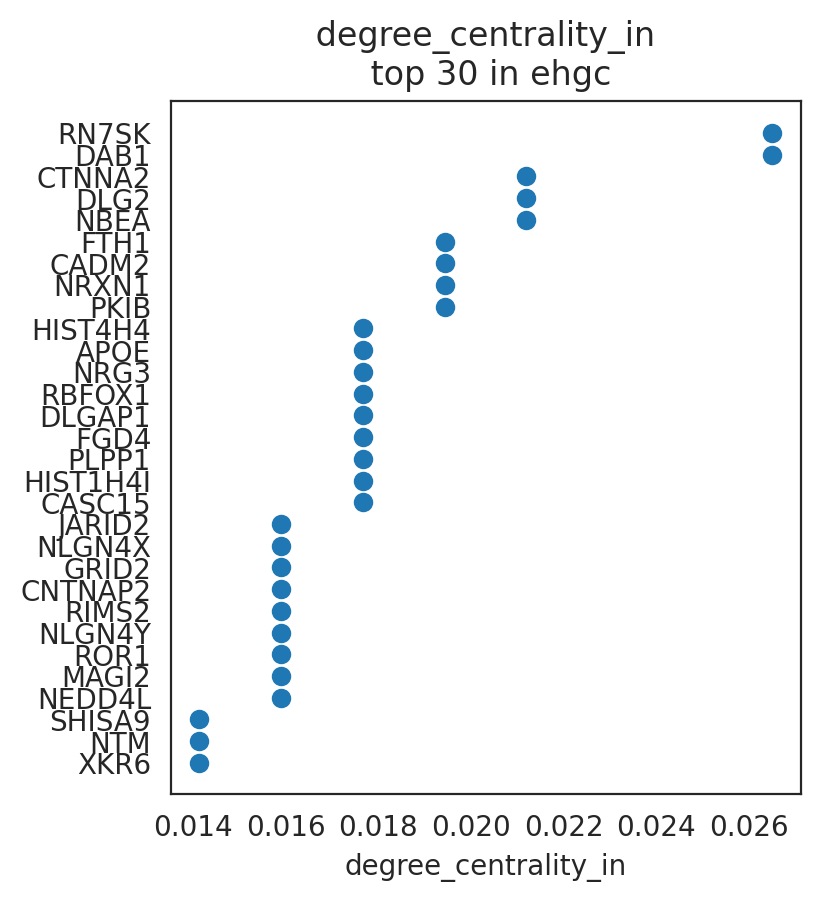

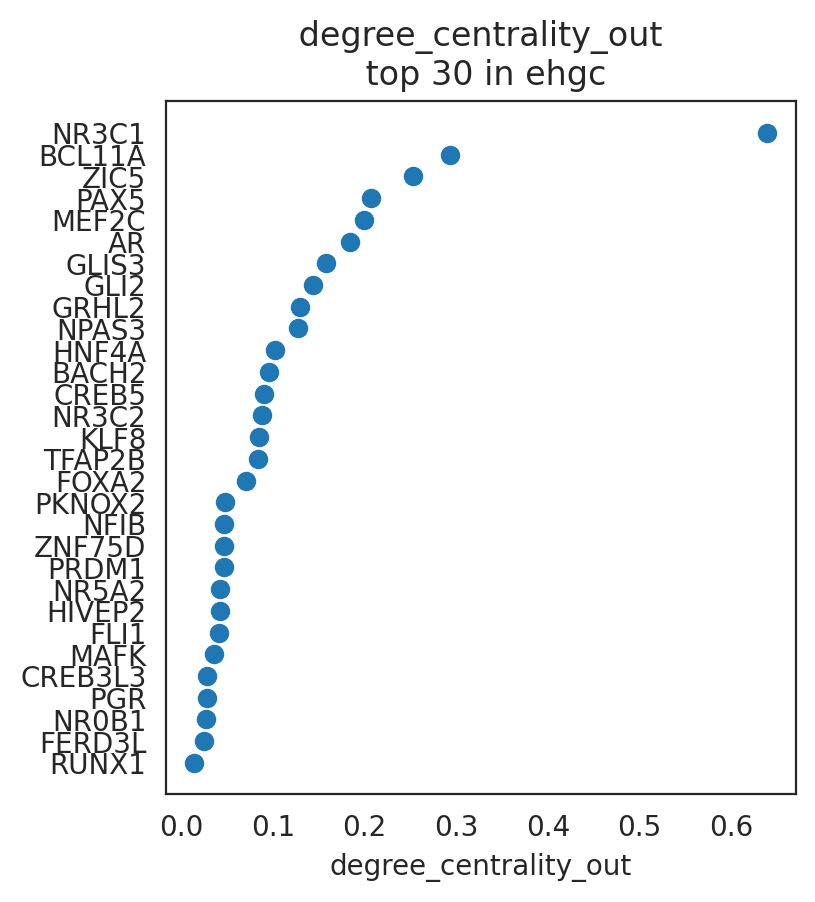

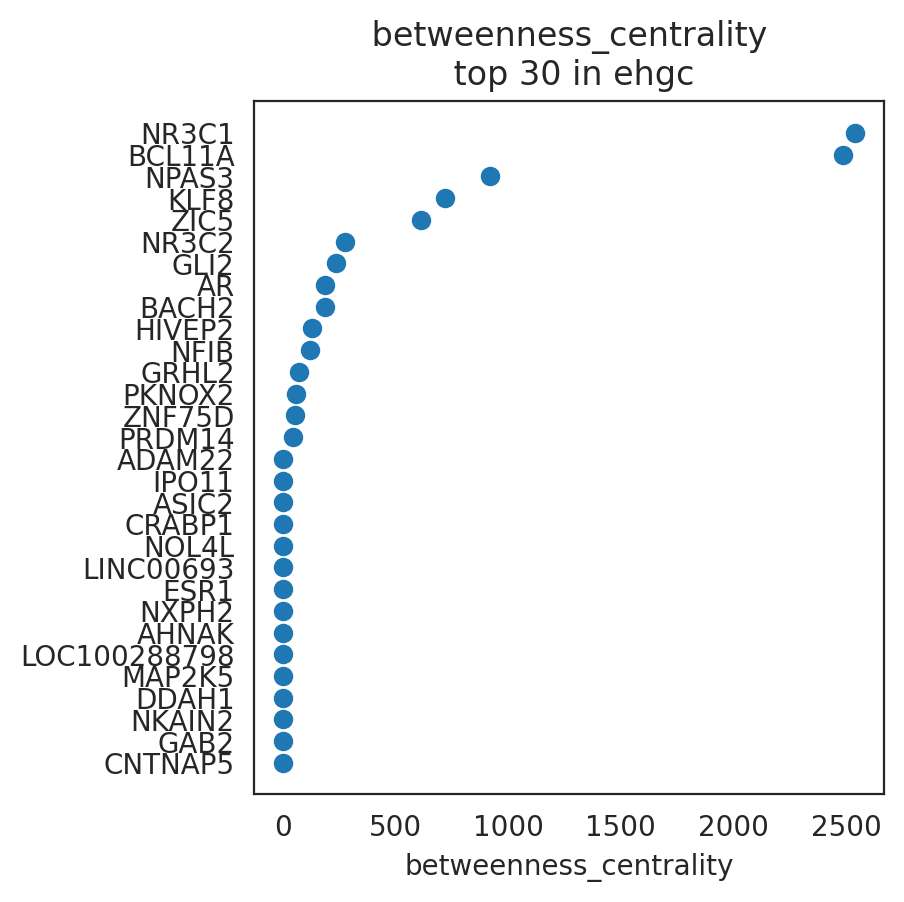

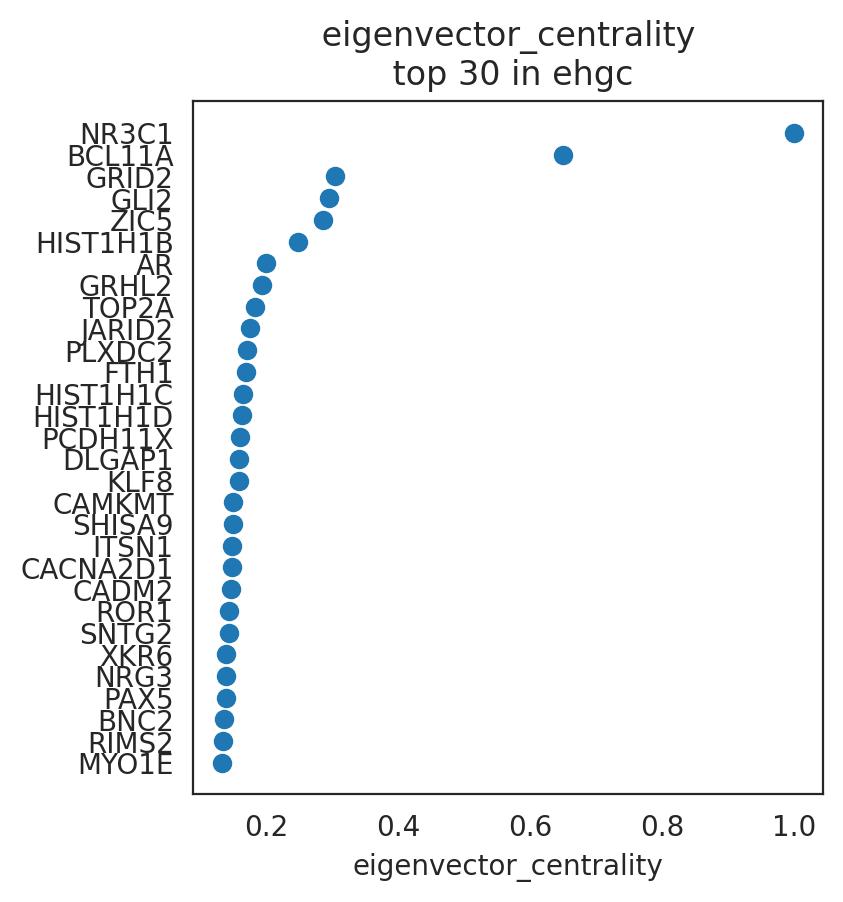

In [60]:
links.plot_scores_as_rank(cluster="ehgc", n_gene=30, save=f"{save_folder}/ranked_score_of_genes")